# 3 · The mathematics behind the models

**Prerequisite:** Steps 1–2. **Destination:** Read the notation used in the book's linear-decomposition, gradient-descent and automatic-differentiation chapters. This is a first working understanding; revisit the examples until you can calculate the tiny cases yourself.

## 1. Vectors: one object with several coordinates

A vector is an ordered collection of numbers. A force can have horizontal and vertical components; a model can have several coefficients. Order matters: $[2,5]$ and $[5,2]$ generally represent different things.

The dot product $a^Tb$ multiplies entries in matching positions and adds: $[2,3]^T[4,-1]=8-3=5$. Geometrically it measures alignment, scaled by lengths. A zero dot product between nonzero vectors means they are perpendicular. A unit vector has L2 length one.

The superscript $T$ transposes rows into columns or vice versa. We conventionally write feature and weight vectors as columns on paper. NumPy's one-dimensional arrays have no row/column distinction, so check array shapes rather than relying on how they print.

## 2. Matrices: a collection of examples or a transformation

Stack feature rows into a matrix $X$. For three examples with intercept feature 1 and inputs $0,1,2$,

$$X=\begin{bmatrix}1&0\\1&1\\1&2\end{bmatrix},\qquad w=\begin{bmatrix}1\\2\end{bmatrix},\qquad Xw=\begin{bmatrix}1\\3\\5\end{bmatrix}.$$

Each output entry is the dot product of one row with $w$. The shape rule is $(N\times d)(d\times1)=(N\times1)$. The inner dimensions must agree. The outer dimensions describe the result.

In Python, `@` is matrix multiplication. `*` multiplies entries elementwise and may broadcast dimensions; it does not mean the same operation. A transpose changes an $N\times d$ matrix into $d\times N$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[1., 0.], [1., 1.], [1., 2.]])
w = np.array([1., 2.])
print("X shape:", X.shape, "w shape:", w.shape)
print("Predictions X @ w:", X @ w)
print("X transpose shape:", X.T.shape)
assert np.allclose(X @ w, [1, 3, 5])

X shape: (3, 2) w shape: (2,)
Predictions X @ w: [1. 3. 5.]
X transpose shape: (2, 3)


An **identity matrix** leaves a vector unchanged: $Iw=w$. An **inverse**, when it exists, reverses a square transformation: $A^{-1}Aw=w$. Not every matrix has an inverse. For computation, use a linear solver instead of explicitly computing an inverse.

Least squares leads, under full column rank, to the normal equations $X^TXw=X^Ty$. The expression $(X^TX)^{-1}X^Ty$ is a useful derivation, but numerical least-squares routines often use more stable factorizations. If two features are identical, many coefficient combinations make the same prediction; their separate effects cannot be uniquely identified from those data.

### Checkpoint 1

For 50 samples and 4 features, give the shapes of $X$, $w$, $Xw$, and $X^TX$. Why is `X * w` not a list of model predictions?

<details><summary>Worked answer</summary>

On paper: $X$ is $50\times4$, $w$ is $4\times1$, $Xw$ is $50\times1$, and $X^TX$ is $4\times4$. In NumPy, a one-dimensional weight array has shape `(4,)`, and predictions have shape `(50,)`. `X * w` multiplies each feature column by its weight but does not add across columns; it leaves a `(50,4)` table.

</details>

## 3. Mean, variance and covariance

The mean $\bar x$ is the average. **Centering** subtracts it from every observation. The sample variance is $\sum_i(x_i-\bar x)^2/(N-1)$; it measures spread in squared units. The sample covariance of two features is $\sum_i(x_i-\bar x)(z_i-\bar z)/(N-1)$. It tends to be positive if both rise together and negative if one rises as the other falls.

Correlation rescales covariance by the two standard deviations and is dimensionless. Zero correlation does not generally imply independence: $z=x^2$ can depend completely on a symmetric zero-mean $x$ while their correlation is zero.

For centered data $X_c$, the covariance matrix is $C=X_c^TX_c/(N-1)$. Its diagonal contains feature variances; its off-diagonal entries contain covariances.

## 4. PCA: find directions that preserve variation

Imagine points forming a thin diagonal cloud in a two-dimensional plot. The horizontal and vertical coordinates both change, but most variation occurs along one diagonal. We can approximate each point by one coordinate along that direction.

An **eigenvector** $v$ of a square matrix satisfies $Cv=\lambda v$: the transformation changes its length but not its direction. For a covariance matrix, eigenvectors identify orthogonal directions of variation, and their nonnegative eigenvalues give the variances in those directions. PCA orders these directions from greatest to least variance.

The **singular value decomposition** is $X_c=U\Sigma V^T$. The columns of $V$ give feature-space directions; singular values in $\Sigma$ tell us their strengths. Their squares divided by $N-1$ are covariance eigenvalues. Retaining the first $k$ directions gives scores $Z=X_cV_k$ and reconstruction $\hat X=ZV_k^T+\bar X$.

For points $(1,1),(2,2),(3,3)$, the mean is $(2,2)$. A principal direction is $(1,1)/\sqrt2$. The centered scores are $-\sqrt2,0,\sqrt2$: one number per point reconstructs these particular data exactly. The sign of a principal direction can be flipped with the corresponding scores without changing reconstruction.

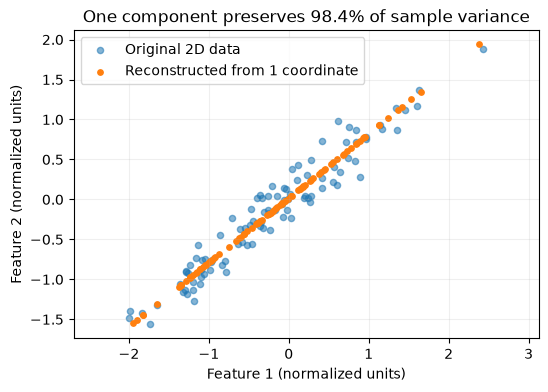

Original shape: (100, 2) compressed shape: (100, 1)


In [2]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(5)
coordinate = rng.normal(size=100)
cloud = np.column_stack([coordinate, 0.8*coordinate + rng.normal(0, 0.18, 100)])
pca = PCA(n_components=1).fit(cloud)
scores = pca.transform(cloud)
reconstruction = pca.inverse_transform(scores)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(cloud[:, 0], cloud[:, 1], s=20, alpha=0.55, label="Original 2D data")
ax.scatter(reconstruction[:, 0], reconstruction[:, 1], s=15, label="Reconstructed from 1 coordinate")
ax.set(xlabel="Feature 1 (normalized units)", ylabel="Feature 2 (normalized units)",
       title=f"One component preserves {pca.explained_variance_ratio_[0]:.1%} of sample variance")
ax.axis("equal"); ax.legend(); ax.grid(alpha=0.2); plt.show()
print("Original shape:", cloud.shape, "compressed shape:", scores.shape)

PCA finds high-variance directions, not necessarily the directions most relevant to predicting a target. Scaling matters: a feature measured in larger units may dominate. Fit any scaling and PCA inside training folds if you use them in a predictive pipeline.

In the course's airfoil example, each geometry is a high-dimensional vector of coordinates. PCA asks how many coordinated shape changes explain much of the observed geometric variation. Sparse PCA, dictionary learning and nonnegative matrix factorization impose different preferences on the representation; they are not just alternate names for PCA.

### Checkpoint 2

PCA component variances are 8, 1 and 1. What fraction does the first component preserve? Does keeping it guarantee the best classifier?

<details><summary>Worked answer</summary>

It preserves $8/(8+1+1)=80\%$. It need not give the best classifier: a low-variance direction could separate the classes. Reconstruction quality and supervised prediction quality answer different questions.

</details>

## 5. Derivatives: how fast does a quantity change?

For $f(x)=x^2$, the average slope from $x$ to $x+h$ is

$$\frac{(x+h)^2-x^2}{h}=2x+h.$$

As $h$ approaches zero, this becomes $2x$. The **derivative** is therefore $f'(x)=2x$. At $x=3$, it is 6: a small change $\Delta x$ changes $f$ by approximately $6\Delta x$. This is a local approximation, not an exact rule for arbitrarily large steps.

Rules we will need:

| Function | Derivative |
|---|---|
| Constant $c$ | 0 |
| $ax+b$ | $a$ |
| $x^n$ | $nx^{n-1}$ |
| $e^x$ | $e^x$ |
| $\log x$, $x>0$ | $1/x$ |
| $f(x)+g(x)$ | $f'(x)+g'(x)$ |

The **chain rule** differentiates a composition: if $u=g(x)$ and $y=f(u)$, then $dy/dx=(dy/du)(du/dx)$. For $y=(3x+1)^2$, the outer derivative is $2(3x+1)$ and the inner derivative is 3, giving $6(3x+1)$.

A **partial derivative** changes one variable while holding others fixed. For $J(w,b)=(wx+b-y)^2$, with observed $x,y$ held fixed,

$$\frac{\partial J}{\partial w}=2(wx+b-y)x,\qquad \frac{\partial J}{\partial b}=2(wx+b-y).$$

The **gradient** collects these partial derivatives into a vector. It points towards steepest local increase under the Euclidean measure of step length, so its negative points downhill.

### Checkpoint 3

For $J(w)=(2w-6)^2$, calculate $J(1)$ and $J'(1)$. Which direction initially decreases the objective?

<details><summary>Worked answer</summary>

$J(1)=16$. Chain rule gives $J'(w)=2(2w-6)\times2=4(2w-6)$, so $J'(1)=-16$. Increasing $w$ initially decreases $J$, because the slope is negative there.

</details>

## 6. Gradient descent: learning as repeated small adjustments

The update is $w_{t+1}=w_t-\eta\nabla J(w_t)$. The subscript $t$ counts optimization steps; $\eta$ is the **learning rate**. For the last checkpoint, starting at $w=1$ with $\eta=0.05$ gives $w_{next}=1-0.05(-16)=1.8$. The new loss is $(3.6-6)^2=5.76$, lower than 16.

Too-small steps may be slow; too-large steps may overshoot or diverge. For the specific objective $(2w-6)^2$, the error around the optimum 3 is multiplied by $1-8\eta$ per update, so convergence requires $0<\eta<0.25$. Other problems have different scales and bounds.

**Batch gradient descent** uses all training examples per update. **SGD** uses a stochastic estimate, often from one example or a small mini-batch. An **epoch** is one pass through the training dataset. Noise in mini-batch gradients is expected; it is not measurement noise and is not necessarily a coding error.

In [3]:
from ipywidgets import interact, FloatSlider

def descent_experiment(learning_rate=0.05):
    w_value = 1.0
    history = [w_value]
    for _ in range(18):
        gradient = 4 * (2*w_value - 6)
        w_value -= learning_rate * gradient
        history.append(w_value)
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.plot(history, marker="o", label="Weight during optimization")
    ax.axhline(3, color="gray", linestyle="--", label="Optimal weight = 3")
    ax.set(xlabel="Update number", ylabel="Weight", title=f"Learning rate η={learning_rate:.3f}")
    ax.legend(); ax.grid(alpha=0.2); plt.show()

interact(descent_experiment, learning_rate=FloatSlider(value=0.05, min=0.005, max=0.30, step=0.005, continuous_update=False));

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='learning_rate', max=0.3, m…

Try 0.01, 0.1, 0.2, 0.25 and 0.3. Explain slow convergence, overshooting, persistent oscillation and divergence using the update rather than memorizing a preferred learning rate.

## 7. Automatic differentiation and backpropagation

A program constructs a **computational graph**: multiply, add, square, and so on. Automatic differentiation applies derivative rules to these operations and combines them with the chain rule. It differs from finite differences, which estimate slopes by evaluating nearby inputs and choosing a small step size.

**Backpropagation** is reverse-mode automatic differentiation applied through a model. It computes gradients. The optimizer uses those gradients to update weights. These are separate operations.

In [4]:
import torch

weight = torch.tensor(1.0, requires_grad=True)
prediction = 2 * weight
loss = (prediction - 6) ** 2
loss.backward()
print("Prediction:", prediction.item(), "Loss:", loss.item(), "Gradient:", weight.grad.item())
assert np.isclose(weight.grad.item(), -16)

Prediction: 2.0 Loss: 16.0 Gradient: -16.0


In a training loop, `optimizer.zero_grad()` clears earlier accumulated gradients, `loss.backward()` computes new ones, and `optimizer.step()` updates parameters. Use the same numeric dtype for tensors that interact. `torch.no_grad()` is useful when evaluating predictions without needing a gradient graph. [PyTorch autograd tutorial](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html).

## 8. Neural networks: learn the features too

A hidden layer computes $h=\sigma(W_1x+b_1)$; an output layer computes $\hat y=W_2h+b_2$. Matrices mix features, and a nonlinear activation such as $\operatorname{ReLU}(z)=\max(0,z)$ changes the representation. Without nonlinear activations, a stack of affine layers collapses to one affine transformation.

Unlike polynomial features fixed by us, hidden representations change during training. The loss still measures mistakes; backpropagation still uses the chain rule; validation is still needed. More layers do not remove any of those obligations.

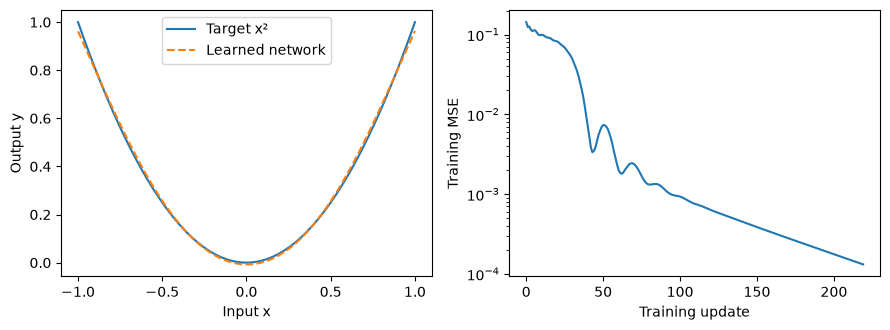

Initial and final training MSE: 0.1432437300682068 0.00013168789155315608


In [5]:
torch.manual_seed(8)
x_tensor = torch.linspace(-1, 1, 60).reshape(-1, 1)
y_tensor = x_tensor ** 2
network = torch.nn.Sequential(torch.nn.Linear(1, 12), torch.nn.Tanh(), torch.nn.Linear(12, 1))
optimizer = torch.optim.Adam(network.parameters(), lr=0.03)
loss_history = []
for _ in range(220):
    optimizer.zero_grad()
    loss = ((network(x_tensor) - y_tensor) ** 2).mean()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
with torch.no_grad():
    fitted_y = network(x_tensor).numpy()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].plot(x_tensor.numpy(), y_tensor.numpy(), label="Target x²")
axes[0].plot(x_tensor.numpy(), fitted_y, "--", label="Learned network")
axes[0].set(xlabel="Input x", ylabel="Output y"); axes[0].legend()
axes[1].plot(loss_history); axes[1].set(xlabel="Training update", ylabel="Training MSE", yscale="log")
fig.tight_layout(); plt.show()
print("Initial and final training MSE:", loss_history[0], loss_history[-1])

This demonstration shows fitting on a synthetic grid; it deliberately makes no claim about test performance. In a scientific experiment you would also define held-out evaluation data.

### Checkpoint 4

Why does a stack of two affine layers without an activation not provide general nonlinear modeling? Does calling `backward()` itself change the learned weights?

<details><summary>Worked answer</summary>

$W_2(W_1x+b_1)+b_2=(W_2W_1)x+(W_2b_1+b_2)$ is still affine in $x$. An activation makes nonlinear representations possible. `backward()` calculates/accumulates gradients; the optimizer's update changes the weights.

</details>

## 9. A small bridge to continuous models

A **Jacobian** is the matrix of partial derivatives of a vector-valued function: entry $(i,j)$ is $\partial f_i/\partial x_j$. It describes how small input changes affect all outputs. Its determinant, when square, describes signed local volume scaling. A **Hessian** is the matrix of second partial derivatives of a scalar function; it describes local curvature. The trace of a square matrix adds its diagonal entries.

An ordinary differential equation (ODE), $dx/dt=v(x,t)$, specifies a rate of change rather than the final state directly. Euler's approximation takes $x_{next}\approx x+\Delta t\,v(x,t)$. For $dx/dt=-x$ and $x(0)=1$, the exact solution is $e^{-t}$. With $\Delta t=0.1$, the first Euler estimate is 0.9; the exact value is approximately 0.9048. The difference is numerical approximation error.

Later, continuous flows learn a vector field $v$ and integrate an ODE. Diffusion introduces stochastic noise as well. You do not need to solve those models now; understand the difference between a state, its rate of change, and a numerical update.

## Ready to continue?

Compute a dot product, explain a PCA projection, differentiate one squared residual, and perform one gradient update by hand. Distinguish backpropagation from optimization. You now have a working entry point for the official chapters on [linear decompositions](../part1/linear_decompositions.ipynb), [gradient descent](../notebooks/supervised_linear_models.ipynb), and [automatic differentiation](../part1/taking_derivatives.ipynb).